# Visualise TCR:pMHC Contact Maps

Visualisations of TCR:pMHC contact maps. CDR loops and peptides are standardised by position relative to the apex of the loop. In cases where the entities length is even, the position to the left of the middle of the loop is taken as the centre.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
contact_map = pd.read_csv('data/processed/tcr_pmhc_contacts.csv')

In [3]:
contact_map['residue_seq_id_pmhc'] = None
contact_map.loc[contact_map['resi_pmhc'].notna(), 'residue_seq_id_pmhc'] = contact_map[
    contact_map['resi_pmhc'].notna()
]['resi_pmhc'].map(
    lambda resi: int(''.join([char for char in resi if char.isnumeric()])),
)

In [4]:
contact_map['chain_type_tcr'] = contact_map['cdr_type'].str[4:]
contact_map['cdr'] = contact_map['cdr_type'].str[3].apply(int)

In [5]:
def gaussian_2d(values: np.ndarray, means: np.ndarray, cov: np.ndarray) -> np.ndarray:
    return (1 / np.sqrt(((2 * np.pi) ** 2) * np.linalg.det(cov))) * np.exp(
        -1 / 2 * (values - means).T @ np.linalg.inv(cov) @ (values - means)
    )

## TCR:Peptide interactions

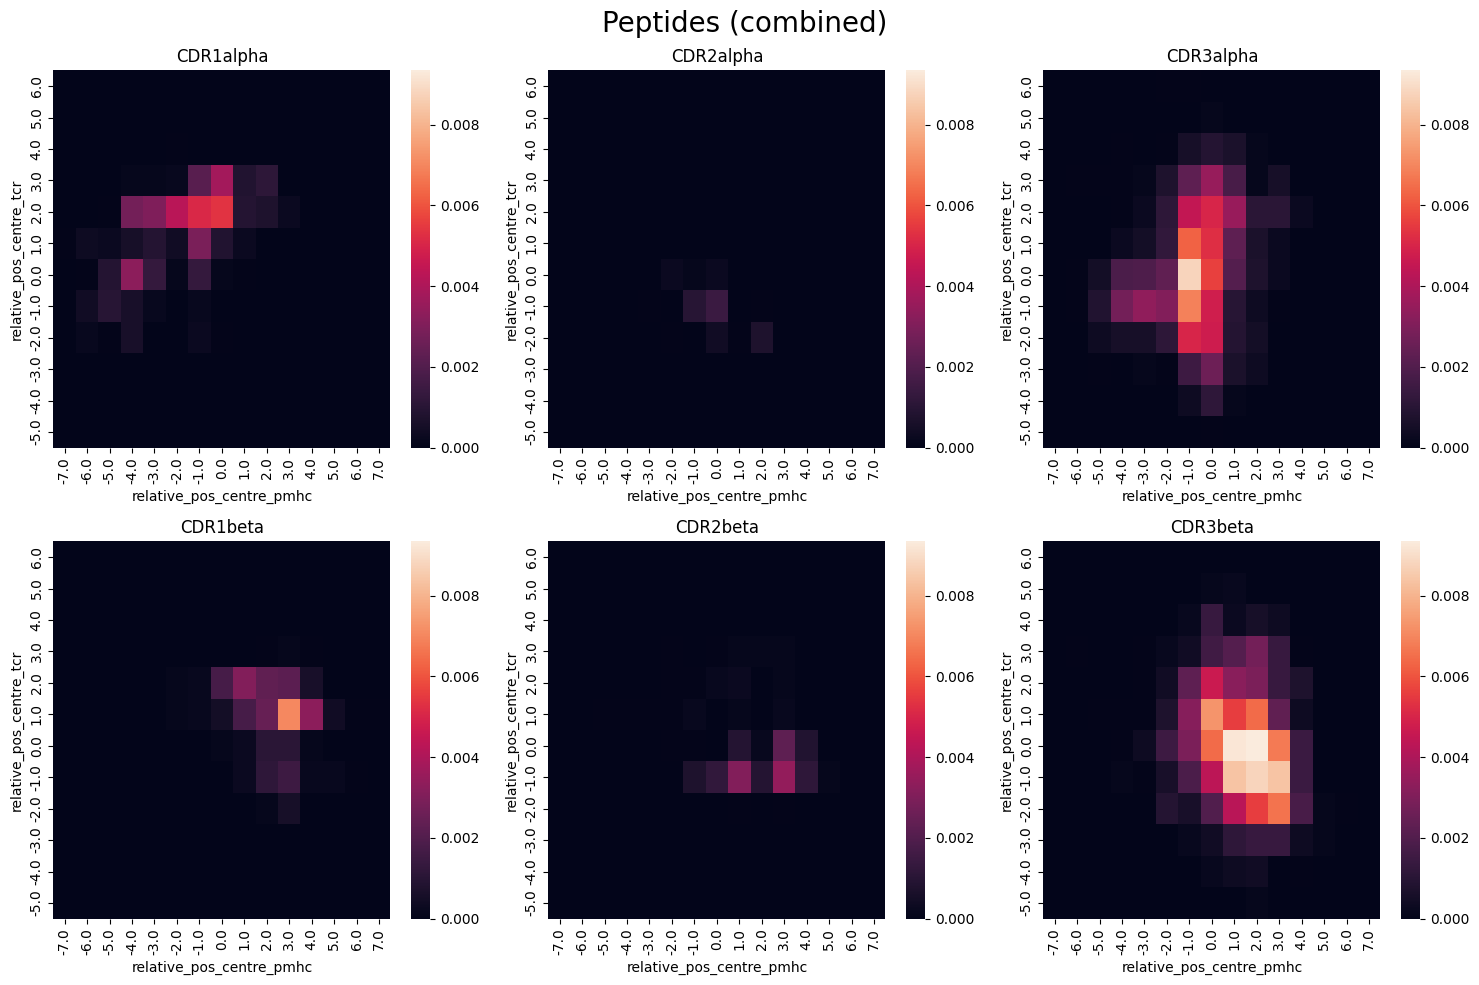

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle('Peptides (combined)', fontsize=20)
fig_data = contact_map[contact_map['chain_type_pmhc'] == 'antigen_chain']
fig_data = (
    fig_data.groupby(
        ['chain_type_tcr', 'cdr', 'relative_pos_centre_tcr', 'relative_pos_centre_pmhc'],
    )['proportion']
    .agg('sum')
    .reset_index()
)

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['relative_pos_centre_pmhc'].unique())
maximum = fig_data['proportion'].max()


for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')

        table = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)].pivot_table(
            index='relative_pos_centre_tcr',
            columns='relative_pos_centre_pmhc',
            values='proportion',
        )

        table[[label for label in x_labels if label not in table.columns]] = np.nan
        missing_table = pd.DataFrame(
            np.nan,
            index=pd.Series([label for label in y_labels if label not in table.index], name=table.index.name),
            columns=table.columns,
        )
        if not missing_table.empty:
            table = pd.concat([table, missing_table])

        table = table[sorted(table.columns)].sort_index(ascending=False)
        table = table.fillna(0)

        sns.heatmap(table, vmax=maximum, ax=axes[i, j])

plt.tight_layout()

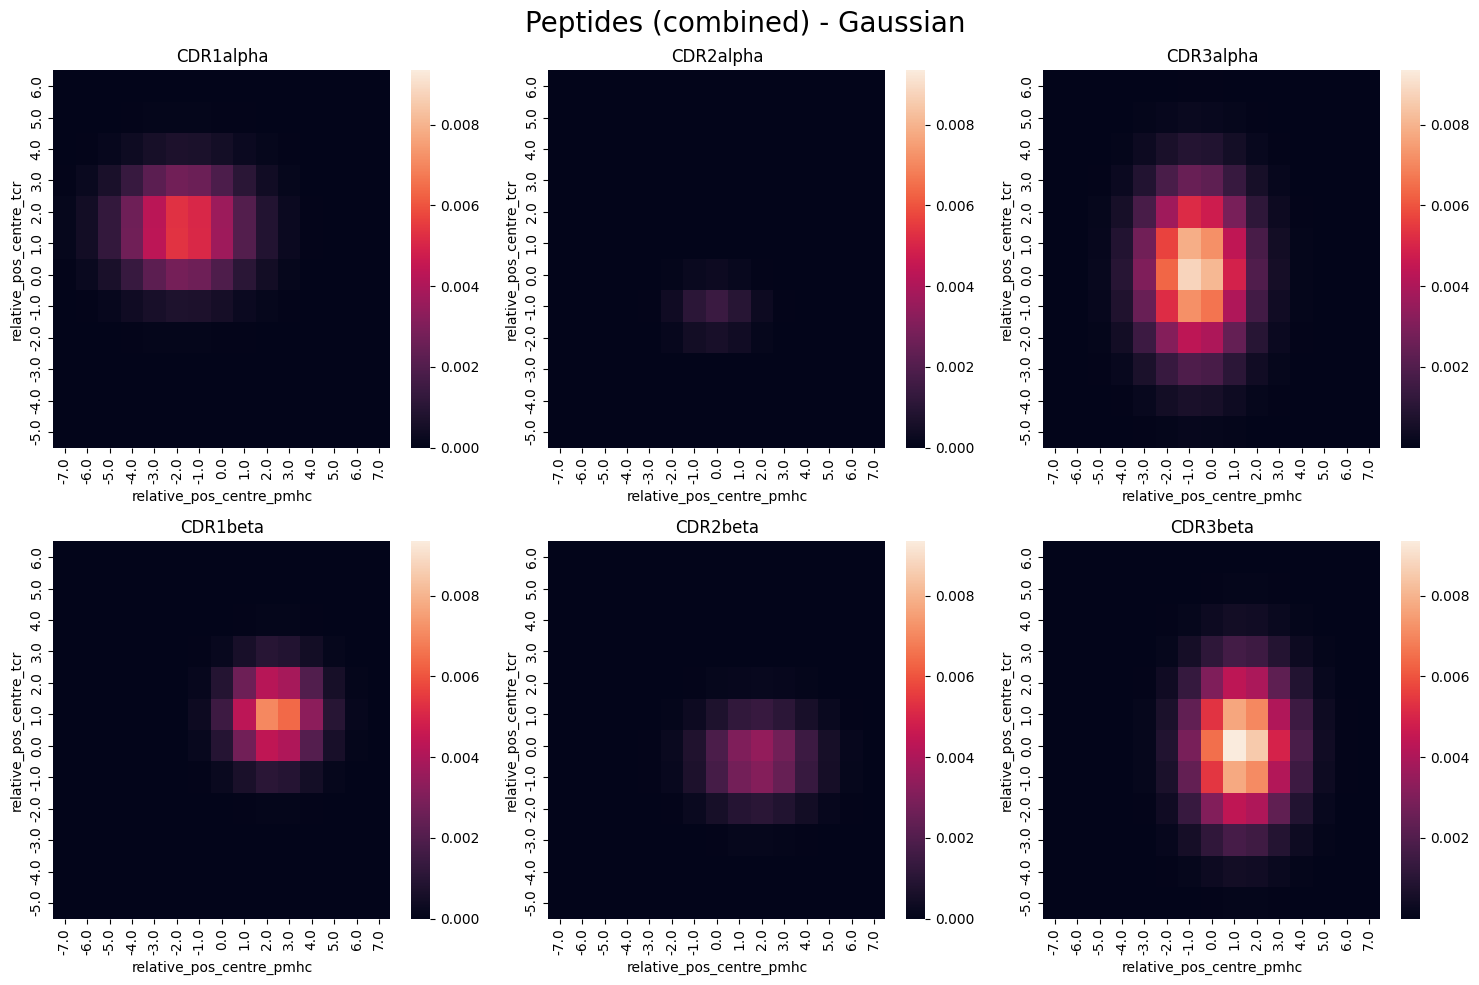

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle('Peptides (combined) - Gaussian', fontsize=20)
fig_data = contact_map[contact_map['chain_type_pmhc'] == 'antigen_chain']
fig_data = (
    fig_data.groupby(
        ['chain_type_tcr', 'cdr', 'relative_pos_centre_tcr', 'relative_pos_centre_pmhc'],
    )['proportion']
    .agg('sum')
    .reset_index()
)

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['relative_pos_centre_pmhc'].unique())

tables = [[None, None, None], [None, None, None]]

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        selected_data = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)]
        group_max = selected_data['proportion'].max()

        x_dist = selected_data.groupby(['relative_pos_centre_pmhc'])['proportion'].sum().reset_index()
        x_mu = np.average(x_dist['relative_pos_centre_pmhc'], weights=x_dist['proportion'])
        x_var = np.average((x_dist['relative_pos_centre_pmhc'] - x_mu) ** 2, weights=x_dist['proportion'])

        y_dist = selected_data.groupby(['relative_pos_centre_tcr'])['proportion'].sum().reset_index()
        y_mu = np.average(y_dist['relative_pos_centre_tcr'], weights=y_dist['proportion'])
        y_var = np.average((y_dist['relative_pos_centre_tcr'] - y_mu) ** 2, weights=y_dist['proportion'])

        means = np.array([x_mu, y_mu])
        cov = np.array([[x_var, 0], [0, y_var]])

        gaussian = []
        for x in x_labels:
            for y in y_labels:
                gauss_xy = gaussian_2d(np.array([x, y]), means, cov)
                gaussian.append([x, y, gauss_xy])

        gaussian = pd.DataFrame(gaussian, columns=['relative_pos_centre_pmhc', 'relative_pos_centre_tcr', 'gaussian'])
        gaussian['gaussian'] = gaussian['gaussian'] * (group_max / gaussian['gaussian'].max())
        table = gaussian.pivot_table(
            values='gaussian',
            index='relative_pos_centre_tcr',
            columns='relative_pos_centre_pmhc',
        )
        table = table[sorted(table.columns)].sort_index(ascending=False)

        tables[i][j] = table

maximum = 0
for i in range(2):
    for j in range(3):
        maximum = max(maximum, tables[i][j].max().max())

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')
        sns.heatmap(tables[i][j], vmax=maximum, ax=axes[i, j])

plt.tight_layout()

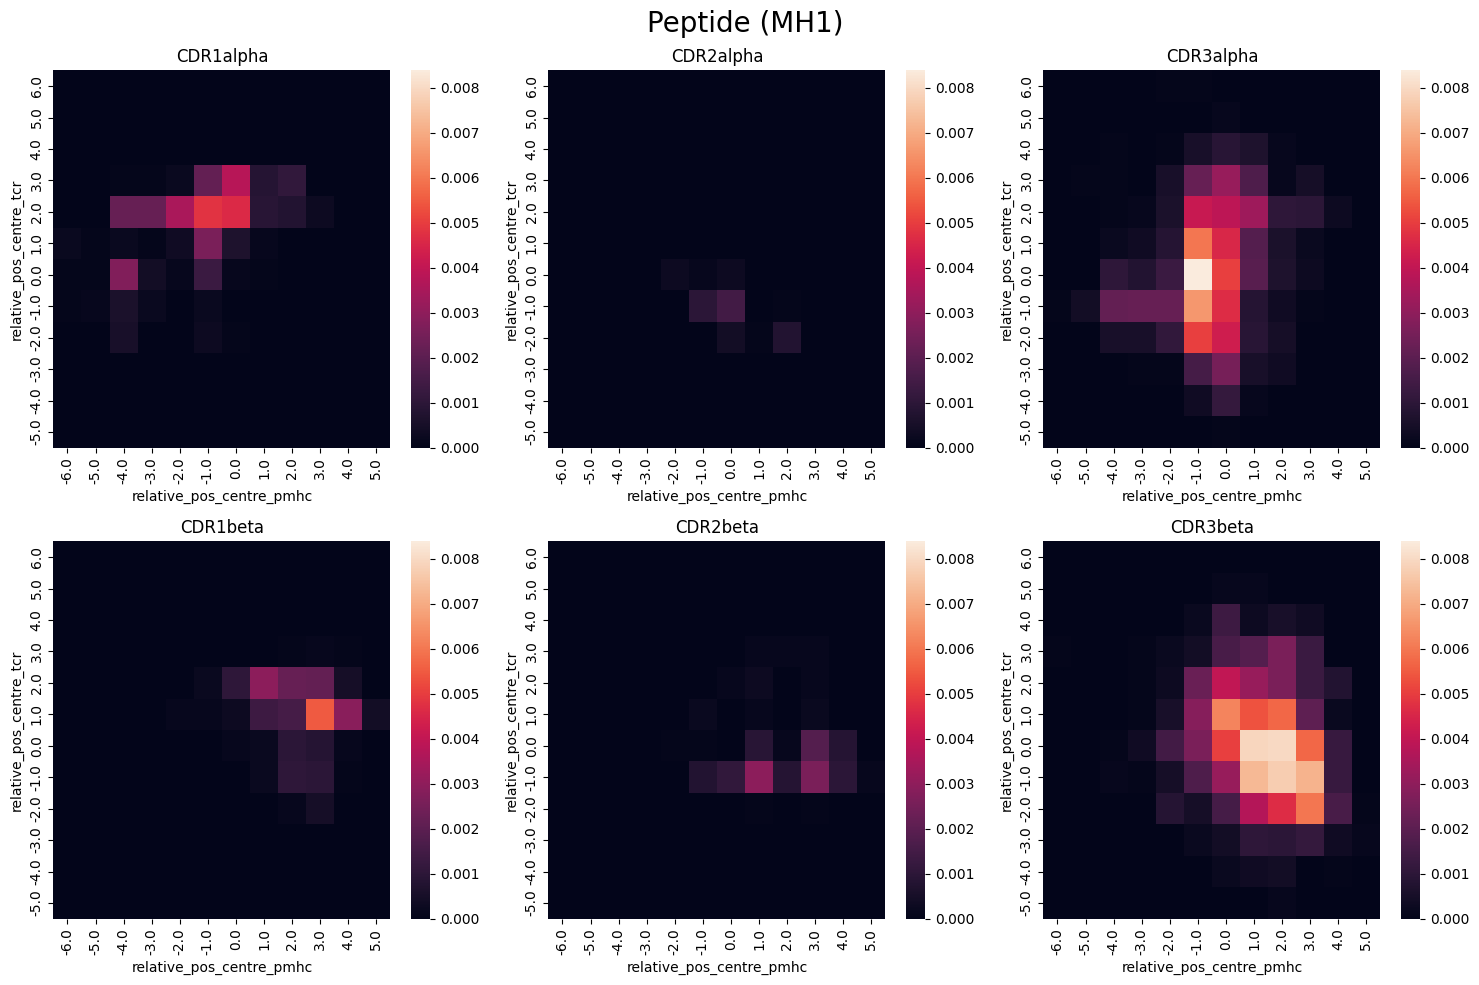

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle('Peptide (MH1)', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH1') & (contact_map['chain_type_pmhc'] == 'antigen_chain')]

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['relative_pos_centre_pmhc'].unique())
maximum = fig_data['proportion'].max()

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')

        table = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)].pivot_table(
            index='relative_pos_centre_tcr',
            columns='relative_pos_centre_pmhc',
            values='proportion',
        )

        table[[label for label in x_labels if label not in table.columns]] = np.nan
        missing_table = pd.DataFrame(
            np.nan,
            index=pd.Series([label for label in y_labels if label not in table.index], name=table.index.name),
            columns=table.columns,
        )
        if not missing_table.empty:
            table = pd.concat([table, missing_table])

        table = table[sorted(table.columns)].sort_index(ascending=False)
        table = table.fillna(0)

        sns.heatmap(table, vmax=maximum, ax=axes[i, j])

plt.tight_layout()

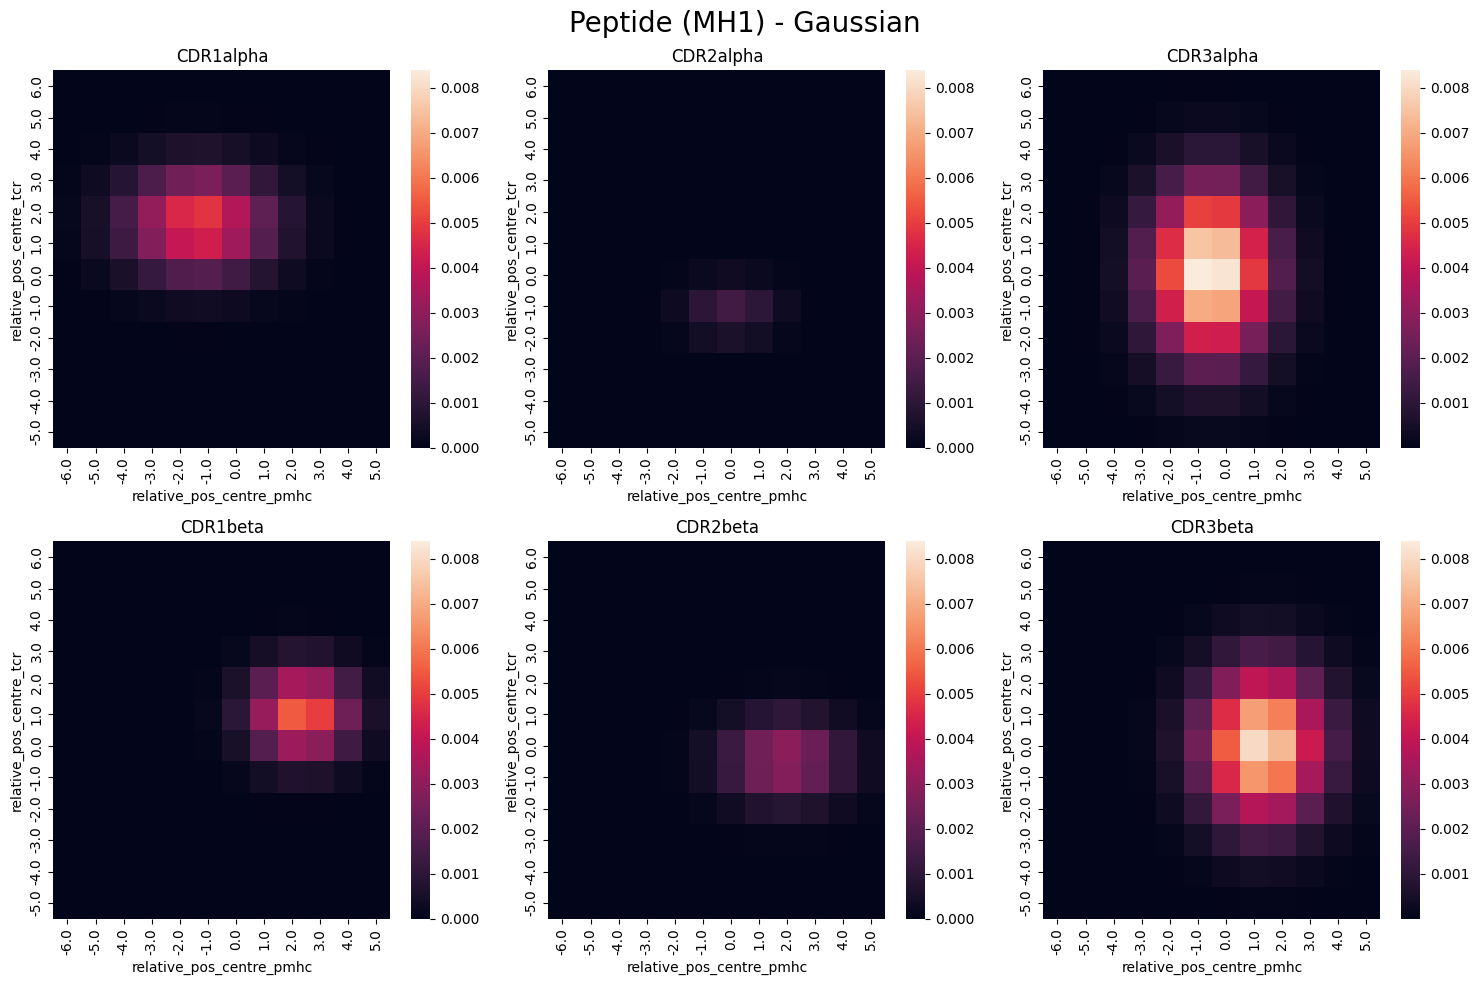

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle('Peptide (MH1) - Gaussian', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH1') & (contact_map['chain_type_pmhc'] == 'antigen_chain')]

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['relative_pos_centre_pmhc'].unique())

tables = [[None, None, None], [None, None, None]]

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        selected_data = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)]
        group_max = selected_data['proportion'].max()

        x_dist = selected_data.groupby(['relative_pos_centre_pmhc'])['proportion'].sum().reset_index()
        x_mu = np.average(x_dist['relative_pos_centre_pmhc'], weights=x_dist['proportion'])
        x_var = np.average((x_dist['relative_pos_centre_pmhc'] - x_mu) ** 2, weights=x_dist['proportion'])

        y_dist = selected_data.groupby(['relative_pos_centre_tcr'])['proportion'].sum().reset_index()
        y_mu = np.average(y_dist['relative_pos_centre_tcr'], weights=y_dist['proportion'])
        y_var = np.average((y_dist['relative_pos_centre_tcr'] - y_mu) ** 2, weights=y_dist['proportion'])

        means = np.array([x_mu, y_mu])
        cov = np.array([[x_var, 0], [0, y_var]])

        gaussian = []
        for x in x_labels:
            for y in y_labels:
                gauss_xy = gaussian_2d(np.array([x, y]), means, cov)
                gaussian.append([x, y, gauss_xy])

        gaussian = pd.DataFrame(gaussian, columns=['relative_pos_centre_pmhc', 'relative_pos_centre_tcr', 'gaussian'])
        gaussian['gaussian'] = gaussian['gaussian'] * (group_max / gaussian['gaussian'].max())
        table = gaussian.pivot_table(
            values='gaussian',
            index='relative_pos_centre_tcr',
            columns='relative_pos_centre_pmhc',
        )
        table = table[sorted(table.columns)].sort_index(ascending=False)

        tables[i][j] = table

maximum = 0
for i in range(2):
    for j in range(3):
        maximum = max(maximum, tables[i][j].max().max())

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')
        sns.heatmap(tables[i][j], vmax=maximum, ax=axes[i, j])

plt.tight_layout()

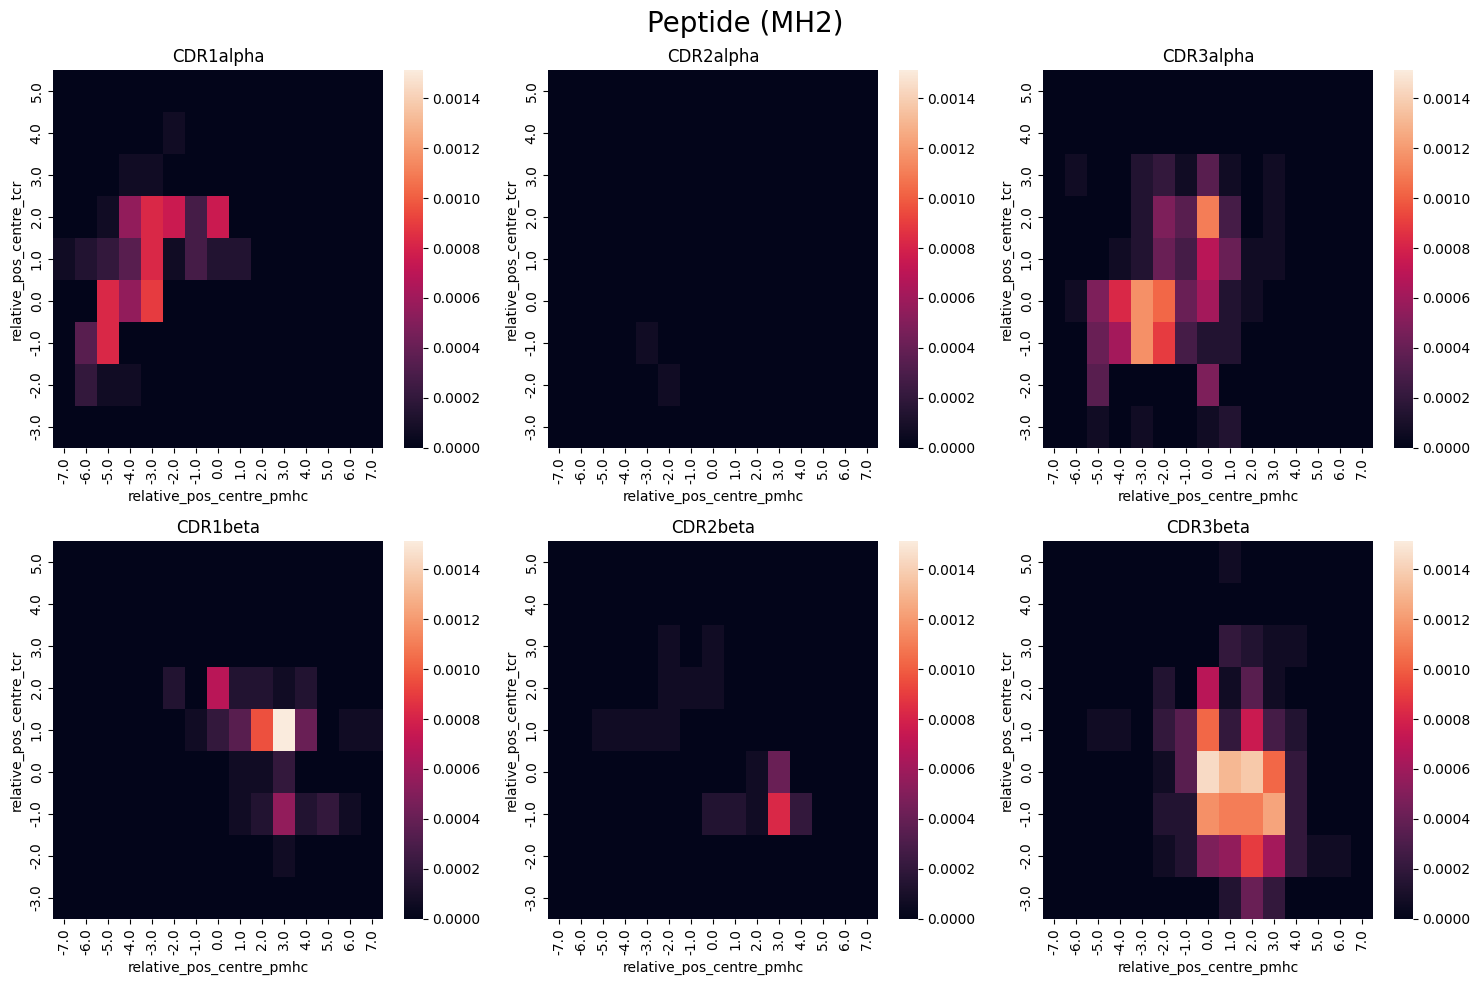

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle('Peptide (MH2)', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH2') & (contact_map['chain_type_pmhc'] == 'antigen_chain')]

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['relative_pos_centre_pmhc'].unique())
maximum = fig_data['proportion'].max()

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')

        table = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)].pivot_table(
            index='relative_pos_centre_tcr',
            columns='relative_pos_centre_pmhc',
            values='proportion',
        )

        table[[label for label in x_labels if label not in table.columns]] = np.nan
        missing_table = pd.DataFrame(
            np.nan,
            index=pd.Series([label for label in y_labels if label not in table.index], name=table.index.name),
            columns=table.columns,
        )
        if not missing_table.empty:
            table = pd.concat([table, missing_table])

        table = table[sorted(table.columns)].sort_index(ascending=False)
        table = table.fillna(0)

        sns.heatmap(table, vmax=maximum, ax=axes[i, j])

plt.tight_layout()

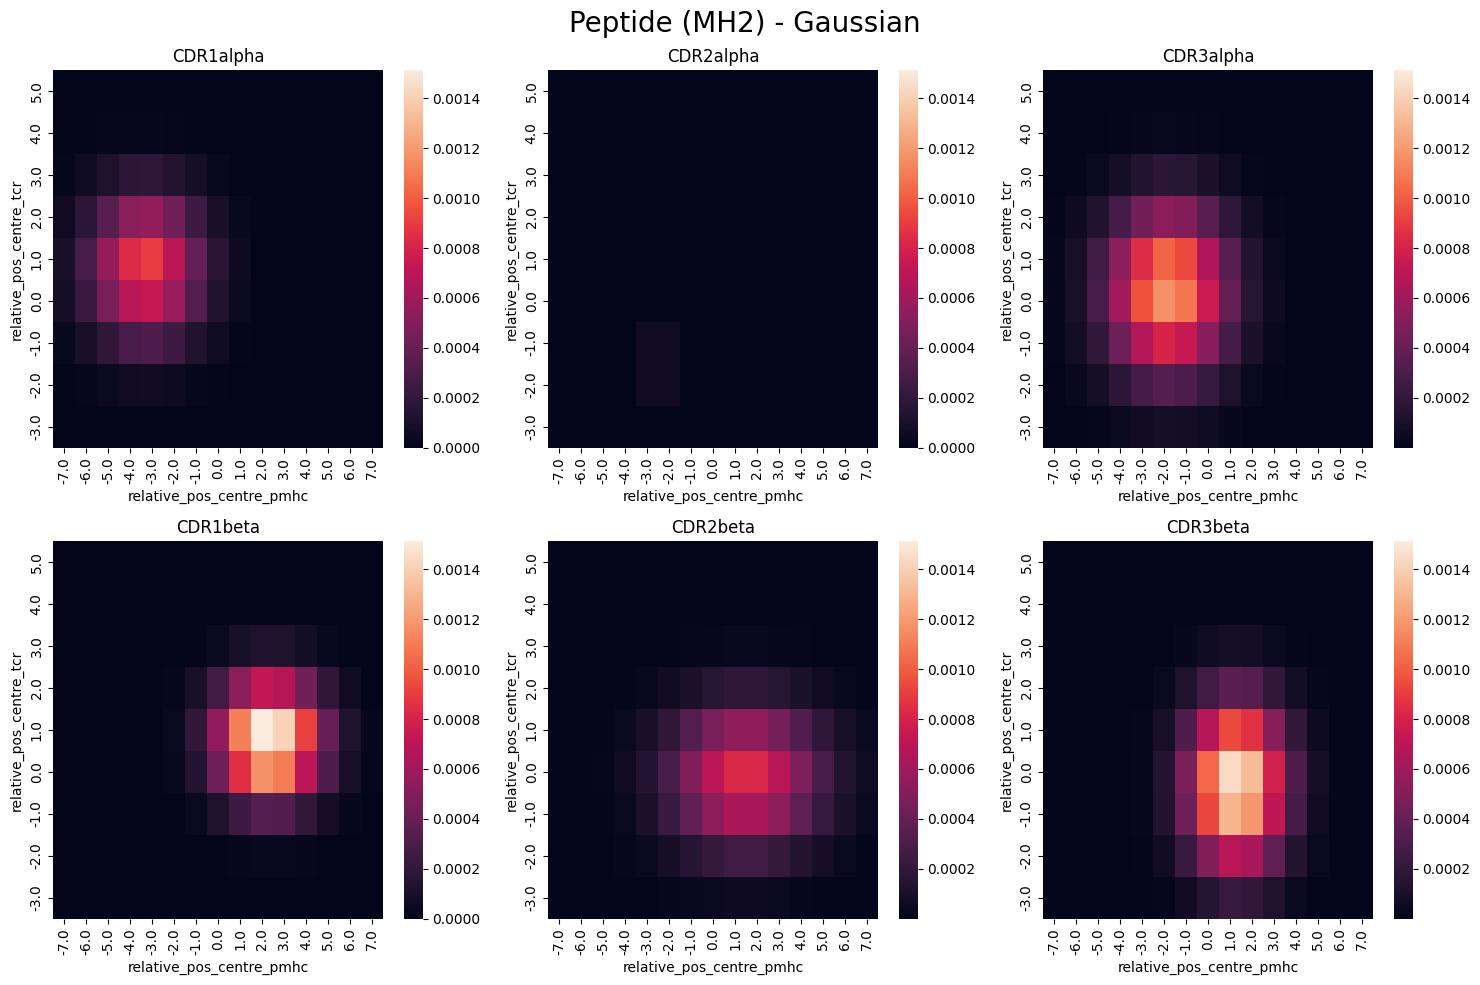

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle('Peptide (MH2) - Gaussian', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH2') & (contact_map['chain_type_pmhc'] == 'antigen_chain')]

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['relative_pos_centre_pmhc'].unique())

tables = [[None, None, None], [None, None, None]]

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        selected_data = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)]
        group_max = selected_data['proportion'].max()

        x_dist = selected_data.groupby(['relative_pos_centre_pmhc'])['proportion'].sum().reset_index()
        x_mu = np.average(x_dist['relative_pos_centre_pmhc'], weights=x_dist['proportion'])
        x_var = np.average((x_dist['relative_pos_centre_pmhc'] - x_mu) ** 2, weights=x_dist['proportion'])

        y_dist = selected_data.groupby(['relative_pos_centre_tcr'])['proportion'].sum().reset_index()
        y_mu = np.average(y_dist['relative_pos_centre_tcr'], weights=y_dist['proportion'])
        y_var = np.average((y_dist['relative_pos_centre_tcr'] - y_mu) ** 2, weights=y_dist['proportion'])

        means = np.array([x_mu, y_mu])
        cov = np.array([[x_var, 0], [0, y_var]])

        gaussian = []
        for x in x_labels:
            for y in y_labels:
                gauss_xy = gaussian_2d(np.array([x, y]), means, cov)
                gaussian.append([x, y, gauss_xy])

        gaussian = pd.DataFrame(gaussian, columns=['relative_pos_centre_pmhc', 'relative_pos_centre_tcr', 'gaussian'])
        gaussian['gaussian'] = gaussian['gaussian'] * (group_max / gaussian['gaussian'].max())
        table = gaussian.pivot_table(
            values='gaussian',
            index='relative_pos_centre_tcr',
            columns='relative_pos_centre_pmhc',
        )
        table = table[sorted(table.columns)].sort_index(ascending=False)

        tables[i][j] = table

maximum = 0
for i in range(2):
    for j in range(3):
        maximum = max(maximum, tables[i][j].max().max())

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')
        sns.heatmap(tables[i][j], vmax=maximum, ax=axes[i, j])

plt.tight_layout()

## TCR:MHC Interactions

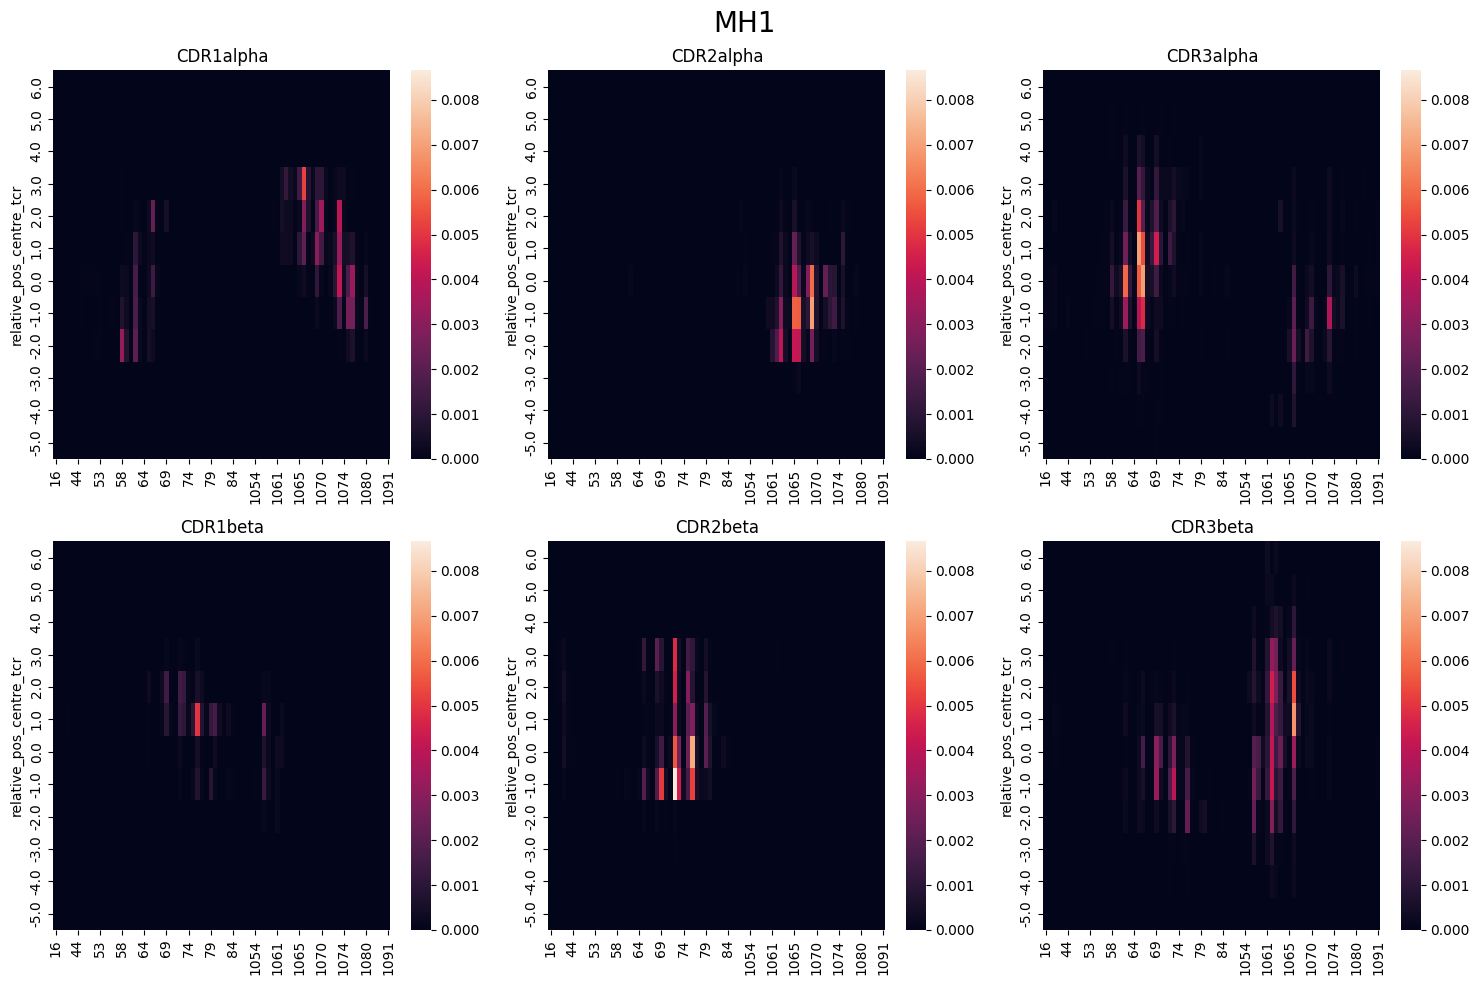

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle('MH1', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH1') & (contact_map['chain_type_pmhc'] != 'antigen_chain')].copy()

fig_data['resi_pmhc'] = fig_data['resi_pmhc'].map(
    lambda resi: (int(''.join([char for char in resi if char.isnumeric()])), '' if resi[-1].isnumeric() else resi[-1]),
)

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['resi_pmhc'].unique())
maximum = fig_data['proportion'].max()

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')

        table = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)].pivot_table(
            index='relative_pos_centre_tcr',
            columns='resi_pmhc',
            values='proportion',
        )

        table[[label for label in x_labels if label not in table.columns]] = np.nan
        missing_table = pd.DataFrame(
            np.nan,
            index=pd.Series([label for label in y_labels if label not in table.index], name=table.index.name),
            columns=table.columns,
        )
        if not missing_table.empty:
            table = pd.concat([table, missing_table])

        table = table[sorted(table.columns)].sort_index(ascending=False)
        table = table.fillna(0)

        table.columns = [f'{seq_id}{insert_code}' for seq_id, insert_code in table.columns]

        sns.heatmap(table, vmax=maximum, ax=axes[i, j])

plt.tight_layout()

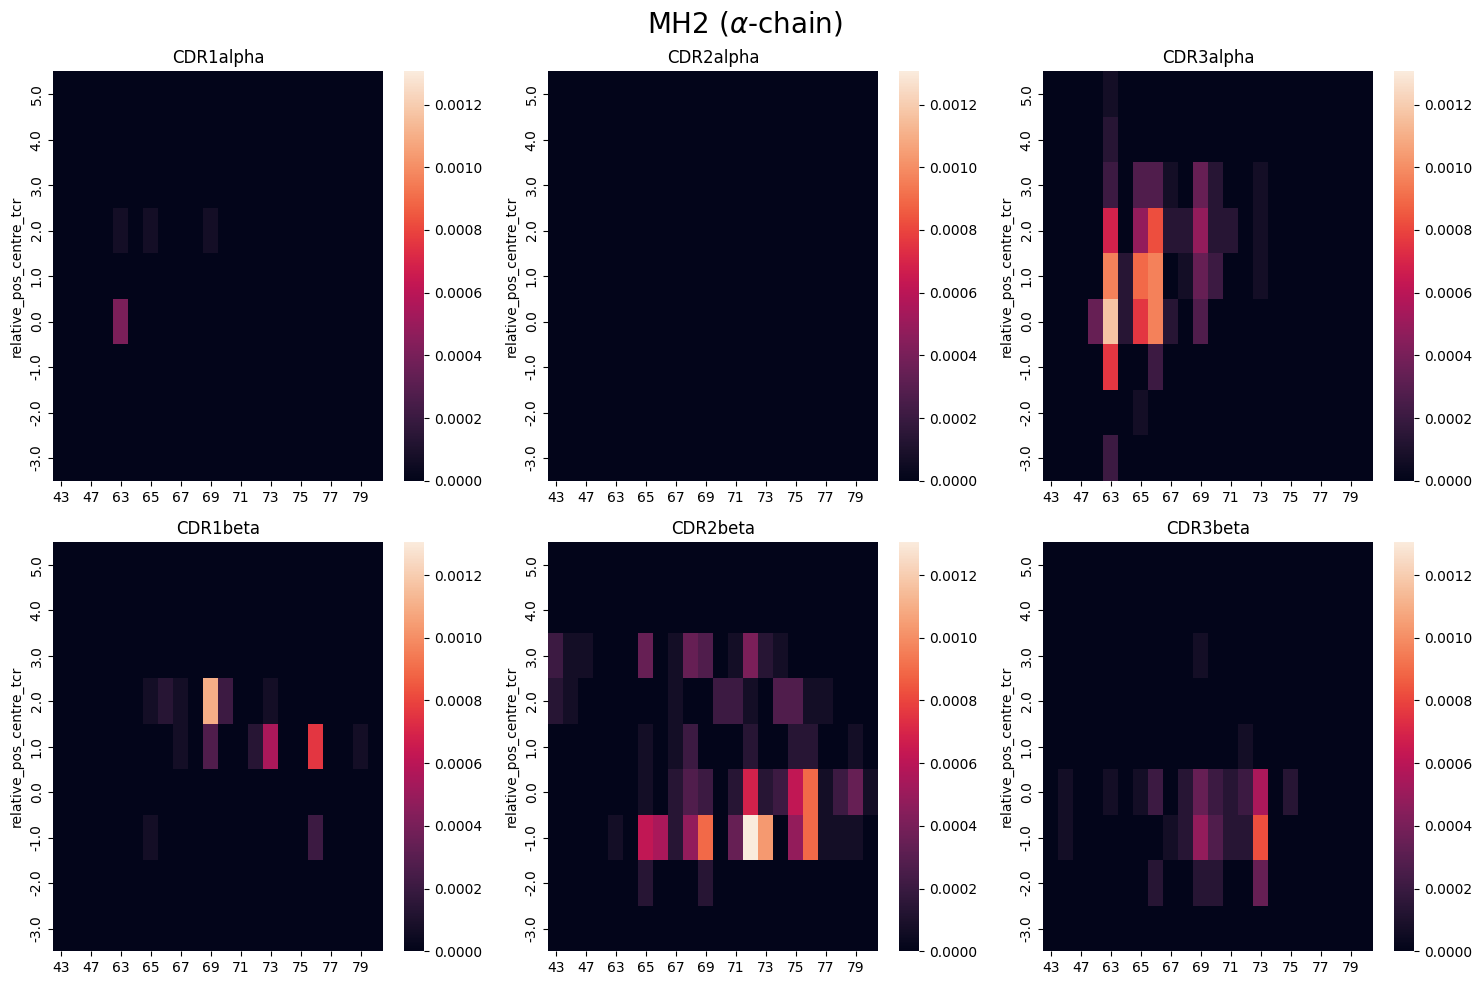

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle(r'MH2 ($\alpha$-chain)', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH2') & (contact_map['chain_type_pmhc'] == 'mhc_chain1')].copy()

fig_data['resi_pmhc'] = fig_data['resi_pmhc'].map(
    lambda resi: (int(''.join([char for char in resi if char.isnumeric()])), '' if resi[-1].isnumeric() else resi[-1]),
)

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['resi_pmhc'].unique())
maximum = fig_data['proportion'].max()

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')

        table = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)].pivot_table(
            index='relative_pos_centre_tcr',
            columns='resi_pmhc',
            values='proportion',
        )

        table[[label for label in x_labels if label not in table.columns]] = np.nan
        missing_table = pd.DataFrame(
            np.nan,
            index=pd.Series([label for label in y_labels if label not in table.index], name=table.index.name),
            columns=table.columns,
        )
        if not missing_table.empty:
            table = pd.concat([table, missing_table])

        table = table[sorted(table.columns)].sort_index(ascending=False)
        table = table.fillna(0)

        table.columns = [f'{seq_id}{insert_code}' for seq_id, insert_code in table.columns]

        sns.heatmap(table, vmax=maximum, ax=axes[i, j])

plt.tight_layout()

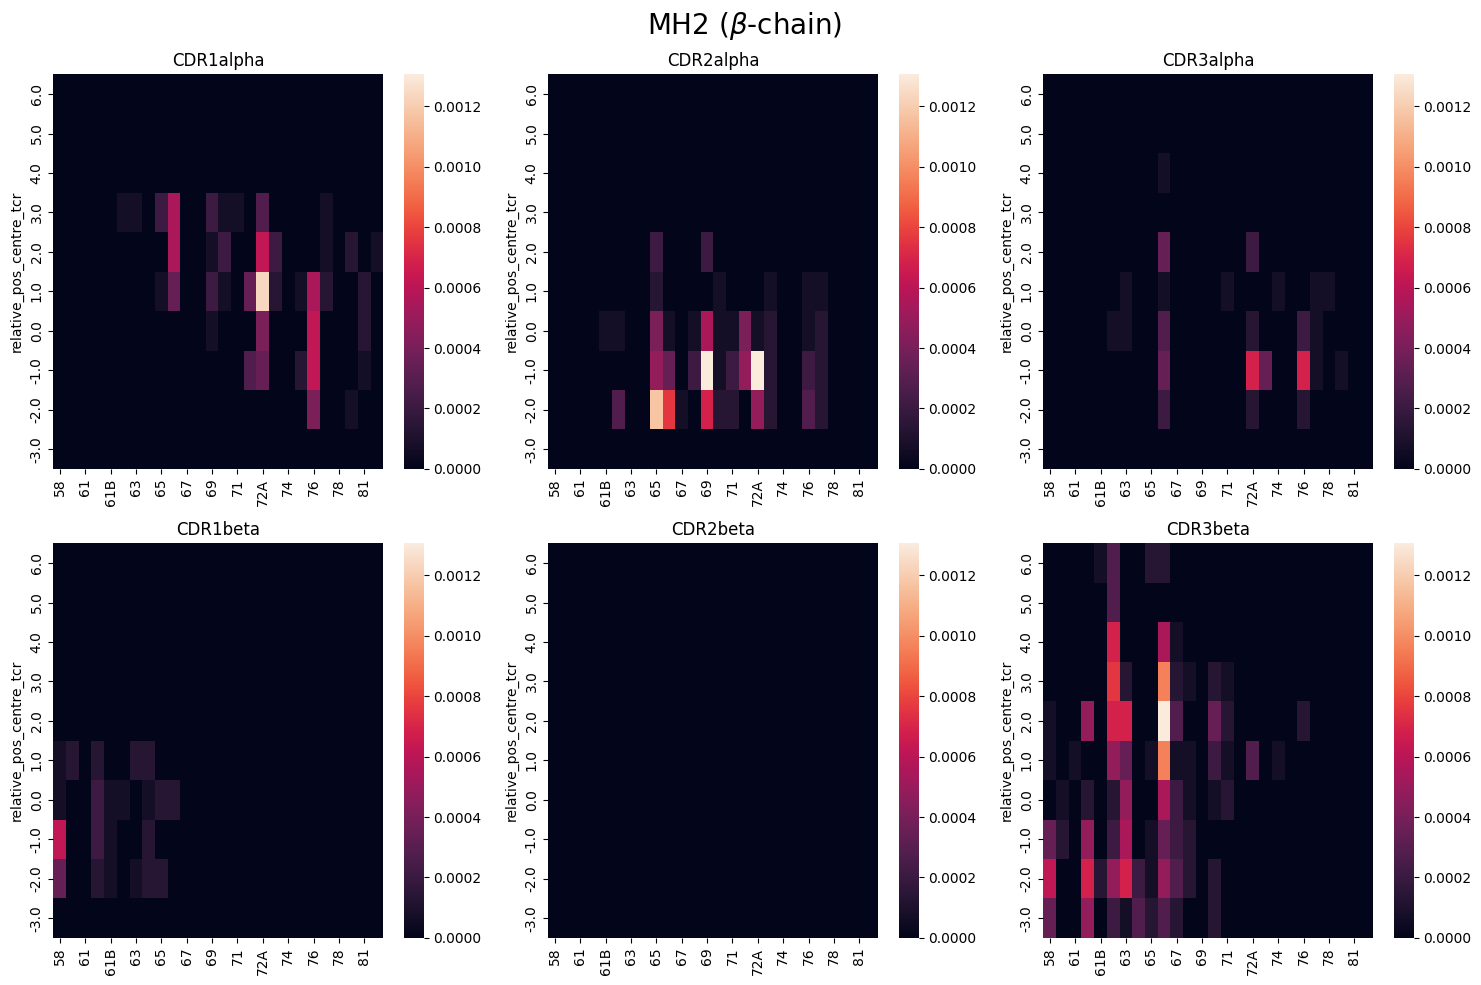

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.suptitle(r'MH2 ($\beta$-chain)', fontsize=20)

fig_data = contact_map[(contact_map['mhc_type'] == 'MH2') & (contact_map['chain_type_pmhc'] == 'mhc_chain2')].copy()

fig_data['resi_pmhc'] = fig_data['resi_pmhc'].map(
    lambda resi: (int(''.join([char for char in resi if char.isnumeric()])), '' if resi[-1].isnumeric() else resi[-1]),
)

y_labels = sorted(fig_data['relative_pos_centre_tcr'].unique())
x_labels = sorted(fig_data['resi_pmhc'].unique())
maximum = fig_data['proportion'].max()

for i, chain_type in enumerate(('alpha', 'beta')):
    for j, cdr in enumerate((1, 2, 3)):
        axes[i, j].set_title(f'CDR{cdr}{chain_type}')

        table = fig_data[(fig_data['chain_type_tcr'] == chain_type) & (fig_data['cdr'] == cdr)].pivot_table(
            index='relative_pos_centre_tcr',
            columns='resi_pmhc',
            values='proportion',
        )

        table[[label for label in x_labels if label not in table.columns]] = np.nan
        missing_table = pd.DataFrame(
            np.nan,
            index=pd.Series([label for label in y_labels if label not in table.index], name=table.index.name),
            columns=table.columns,
        )
        if not missing_table.empty:
            table = pd.concat([table, missing_table])

        table = table[sorted(table.columns)].sort_index(ascending=False)
        table = table.fillna(0)

        table.columns = [f'{seq_id}{insert_code}' for seq_id, insert_code in table.columns]

        sns.heatmap(table, vmax=maximum, ax=axes[i, j])

plt.tight_layout()